In [41]:
using WaveSpec

In [42]:
using WaveSpec.AngularSpreading
using WaveSpec.ContinuousSpectrums
using WaveSpec.SpectralSpreading
using WaveSpec.FrequencySampling
using WaveSpec.AiryWaves
using Distributions
using Plots

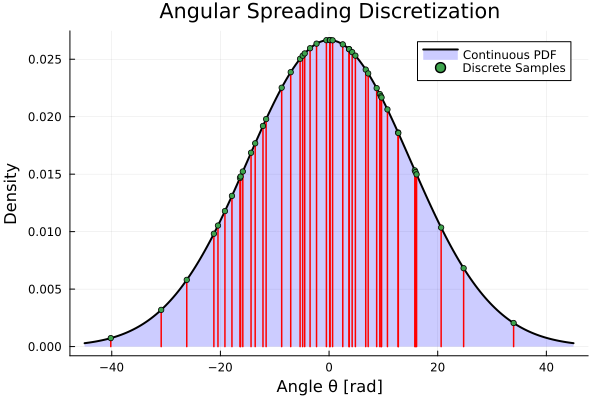

In [43]:
# Generate angular spreading structure
μ = 0.0
σ = 15.0
θmin = -45.0
θmax = 45.0
nθ = 45
AngSprea = SpreadingModel(:normal, μ, σ, θmin, θmax, nθ) 

# 1. Continuous PDF
θ_range = range(AngSprea.distribution.a, AngSprea.distribution.b, length=200)
pdf_vals = [pdf(AngSprea.distribution, θ) for θ in θ_range]

p = plot(θ_range, pdf_vals, 
            label="Continuous PDF", 
            linecolor=:black, lw=2, fill=(0, 0.2, :blue))

# 2. Discrete Samples
θ_samples = get_angles(AngSprea)
# We plot them as vertical lines (stems) with height = pdf value
weights = [pdf(AngSprea.distribution, θ) for θ in θ_samples]

collect_θ = []
collect_w = []
for (t, w) in zip(θ_samples, weights)
    push!(collect_θ, t, t, NaN)
    push!(collect_w, 0, w, NaN)
end

plot!(p, collect_θ, collect_w, label=false, 
        linecolor=:red, lw=1.5)
scatter!(p, θ_samples, weights, label="Discrete Samples", marker=:circle, markersize=3)

xlabel!("Angle θ [rad]")
ylabel!("Density")
title!("Angular Spreading Discretization")

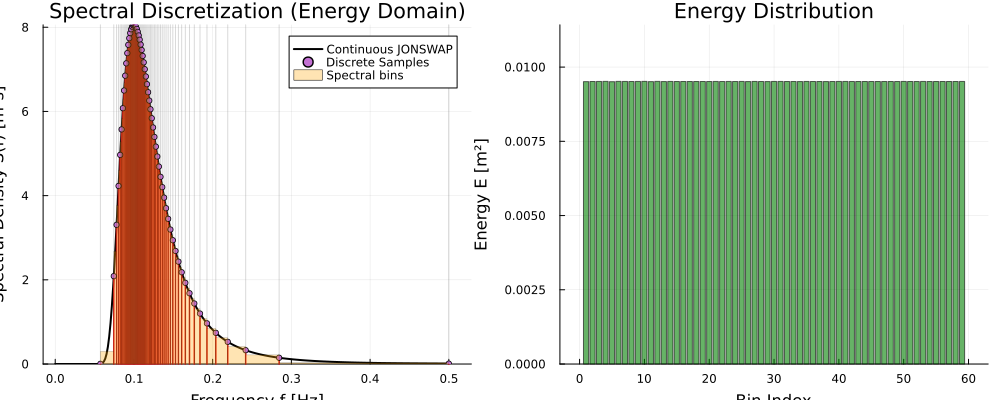

In [44]:
# Generate continuous spectrum model 
Hs = 3.0
Tp = 10.0
Cspec = JONSWAP(Hs, Tp)

# Generate discrete spectrum 
nf = 60
Dspec = DiscreteSpectrum(Cspec, UniformSampling(), get_fmin(Cspec), get_fmax(Cspec), nf; 
                        domain=FrequencySampling.Energy, mess=false)

# 1. Continuous Model
f_range = range(get_fmin(Cspec), get_fmax(Cspec), length=300)
S_cont = [ContinuousSpectrums.get_density(Cspec, f) for f in f_range]

# 2. Get Discrete Data
f_edges = SpectralSpreading.get_frequencies(Dspec)                           # Edge frequencies
S_edges = [ContinuousSpectrums.get_density(Cspec, f) for f in f_edges]       # Density at edge frequencies
f_centers = SpectralSpreading.get_central_frequencies(Dspec)                 # Central frequencies
Δf = diff(f_edges)                                                           # Widths of each bin
S_centers = [ContinuousSpectrums.get_density(Cspec, f) for f in f_centers]  # Density at central frequencies (S_j)

collect_f = []
collect_S = []
for (f, w) in zip(f_edges, S_edges)
    push!(collect_f, f, f, NaN)
    push!(collect_S, 0, w, NaN)
end

# 3. Energy per Bin Calculation
# We calculate E_j = ∫ S(f) df over the bin limits [f_low, f_high]  using the high-resolution CDF
E_bins = zeros(Dspec.nbands)
n_substeps = 100
for i in 1:Dspec.nbands
    # 1. Define the bin boundaries
    f_start = f_edges[i]
    f_end   = f_edges[i+1]
    
    # 2. Create a micro-grid inside this specific bin
    # We sample n_substeps points to capture the curve's shape
    f_micro = range(f_start, f_end, length=n_substeps)
    df = (f_end - f_start) / (n_substeps - 1)
    
    # 3. Integrate S(f) using the Trapezoidal Rule
    bin_energy = 0.0
    for j in 1:(n_substeps - 1)
        S0 = ContinuousSpectrums.get_density(Cspec, f_micro[j])
        S1 = ContinuousSpectrums.get_density(Cspec, f_micro[j+1])
        
        # Area of a small trapezoid: (average height) * width
        bin_energy += 0.5 * (S0 + S1) * df
    end
    # Save energy
    E_bins[i] = bin_energy
end

# --- Plotting ---
p1 = plot(f_range, S_cont, label="Continuous JONSWAP", 
            linecolor=:black, lw=2)

# 3. Plot spectral samples 
plot!(p1, collect_f, collect_S, label=false, 
        linecolor=:red, lw=1.5)
vline!(f_edges, color=:gray, alpha=0.3, label=false)
scatter!(p1, f_edges, S_edges, label="Discrete Samples", marker=:circle, markersize=3)

# 4. Plot the "Energy Bins" as a bar chart
# bar_width takes a vector, allowing each bar to have its specific width
bar!(p1, f_centers, S_centers, 
     bar_width = Δf,           # This makes them span the actual bin width
     alpha = 0.3, 
     label = "Spectral bins", 
     color = :orange, 
     linewidth = 0.5)

xlabel!(p1, "Frequency f [Hz]")
ylabel!(p1, "Spectral Density S(f) [m²s]")
title!(p1, "Spectral Discretization (Energy Domain)")

# Right plot: Energy bins
# p2 = bar(f_centers, E_bins, 
#          label=false, 
#          color=:green, alpha=0.6,
#          ylims=(0, maximum(E_bins)*1.2))
p2 = bar(range(1,Dspec.nbands), E_bins, 
         label=false, 
         color=:green, alpha=0.6,
         ylims=(0, maximum(E_bins)*1.2))
xlabel!(p2, "Bin Index")
ylabel!(p2, "Energy E [m²]")
title!(p2, "Energy Distribution")

# Combine them
plot(p1, p2, layout=(1, 2), size=(1000, 400))

In [45]:
# Generate Airy sea state
h = 2.0
airysea = AiryState(Dspec, AngSprea, h)

AiryState(DiscreteSpectrum(JONSWAP{Float64}(3.0, 10.0, 0.1, 1.0, 1.0000078065322076, 0.6283185307179586, 0.07, 0.09), UniformSampling(), EnergyDomain(), 1.0e-5, 0.5, 60, 59, 1.0164844001817674), SpreadingModel{Normal{Float64}, Float64}(WaveSpec.Truncation.TruncatedModel{Normal{Float64}, Float64}(
dist: Normal{Float64}(μ=0.0, σ=15.0)
a: -45.0
b: 45.0
Z: 0.9973002039367398
cdf_a: 0.001349898031630093
cdf_b: 0.9986501019683699
)
, 45, 5915871357375395971), 59, 44, [0.41402337530439914, 0.4786092295995262, 0.49768227810866855, 0.5121146183170031, 0.5242769923568005, 0.5350706678082363, 0.5449525867459093, 0.5541806335060269, 0.5629277049364667, 0.5713140771634447  …  1.0239016545408772, 1.0550658348535573, 1.0908711451745614, 1.1328446667713115, 1.1833549980164522, 1.2463773515573051, 1.3293294246717542, 1.4485638941783743, 1.653676915208601, 2.4644147478965786], [0.09403483899207367, 0.10891883395863589, 0.11333176162157015, 0.11667666501359931, 0.11949940501798491, 0.12200757865546678, 0

In [46]:
# Define spatial grid: 100m x 100m
nx, ny = 100, 100
x_coords = range(-50.0, 50.0, length=nx)
y_coords = range(-50.0, 50.0, length=ny)

# Time and vertical position (surface)
t_val = [0.0]
z_val = [0.0]

1-element Vector{Float64}:
 0.0

In [47]:
profiles = sea_profiles(airysea, x_coords, y_coords, z_val, t_val, vars=[:η])

(η = [-0.976863678498272 -1.1848875239149317 … 0.9135914064213371 0.9338263959573948; -0.8706072853133547 -1.0970830808950864 … 0.7164544240109897 0.7240103087482166; … ; 0.2584725266888764 0.2685733626065139 … -0.8067162160864546 -0.9278658293435357; 0.12444870041219387 0.1652358968278439 … -0.6973481332072982 -0.7859218391217634;;;;],)

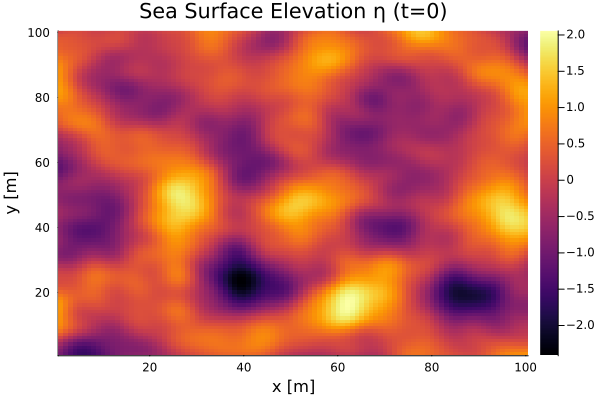

In [48]:
# Plotting
p1 = heatmap(profiles.η[:,:,1,1], 
             colorbar=true, 
             title="Sea Surface Elevation η (t=0)",
             xlabel="x [m]", ylabel="y [m]")